# Eredivisie 2025-2026 -- exploring the aggregated data

Loads `player_season_aggregated.csv` and `team_season_aggregated.csv`
(393 player metrics / season, built by `build_season_aggregate.py`) and walks
through a few of the tabs from `eredivisie_2025-2026_aggregated.xlsx`:
progression, creativity (including the delivery-type breakdown -- xA from a
cutback vs. a cross vs. a through ball, not just one blended "xA"),
possession-adjusted defensive volume, and the team table.

Column names here are relabelled with `display_names.display_name()` for
reading -- the underlying CSVs keep their exact snake_case names, see
`README.md` in this folder for the full definitions and caveats before
trusting any single number.

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, os.path.join(ROOT, "Aggregated"))
sys.path.insert(0, ROOT)

from display_names import display_name
from housestyle import style, components

SEASON = "2025-2026"
DATA_DIR = os.path.join(ROOT, "Aggregated", SEASON)

players = pd.read_csv(os.path.join(DATA_DIR, "player_season_aggregated.csv"))
teams = pd.read_csv(os.path.join(DATA_DIR, "team_season_aggregated.csv"))

def relabel(df):
    return df.rename(columns={c: display_name(c) for c in df.columns})

reliable = players[players["reliable_sample"]]
print(f"{len(players)} players ({len(reliable)} with >=450 minutes), {len(teams)} teams")

553 players (355 with >=450 minutes), 18 teams


## Progression -- reading `progressive_passes` with the known caveat applied

The Glossary flags that goalkeepers can top this leaderboard on raw distance
gained through long distribution. Filtering to outfield players (no `gk_`
activity) before ranking, exactly as the README recommends.

In [2]:
outfield = reliable[reliable["gk_saves"] + reliable["gk_claims"] + reliable["gk_pickups"] == 0]
cols = ["player_name", "team_name", "progressive_passes_per90", "progressive_carries_per90",
        "final_third_entries_per90", "total_box_entries_per90"]
top_prog = outfield.nlargest(10, "progressive_passes_per90")[cols]
relabel(top_prog).set_index("Player").round(2)

,Team,Progressive Passes /90,Progressive Carries /90,Final 3rd Entries /90,Box Entries /90
Player,,,,,
Y. Namli,PEC Zwolle,6.73,1.15,4.43,1.80
A. Hadj Moussa,Feyenoord Rotterdam,5.45,0.96,1.83,2.89
Raúl Moro,AFC Ajax,5.36,1.45,2.17,3.33
K. Fitz-Jim,AFC Ajax,5.15,1.18,6.04,1.18
J. Wieckhoff,Heracles Almelo,5.08,0.78,3.22,1.17
D. van der Werff,FC Groningen,4.98,0.57,3.60,1.47
O. Gloukh,AFC Ajax,4.93,1.50,5.15,2.31
R. Daal,Alkmaar Zaanstreek,4.56,0.96,1.99,3.08
B. Ould-Chikh,FC Volendam,4.49,0.78,1.27,2.15


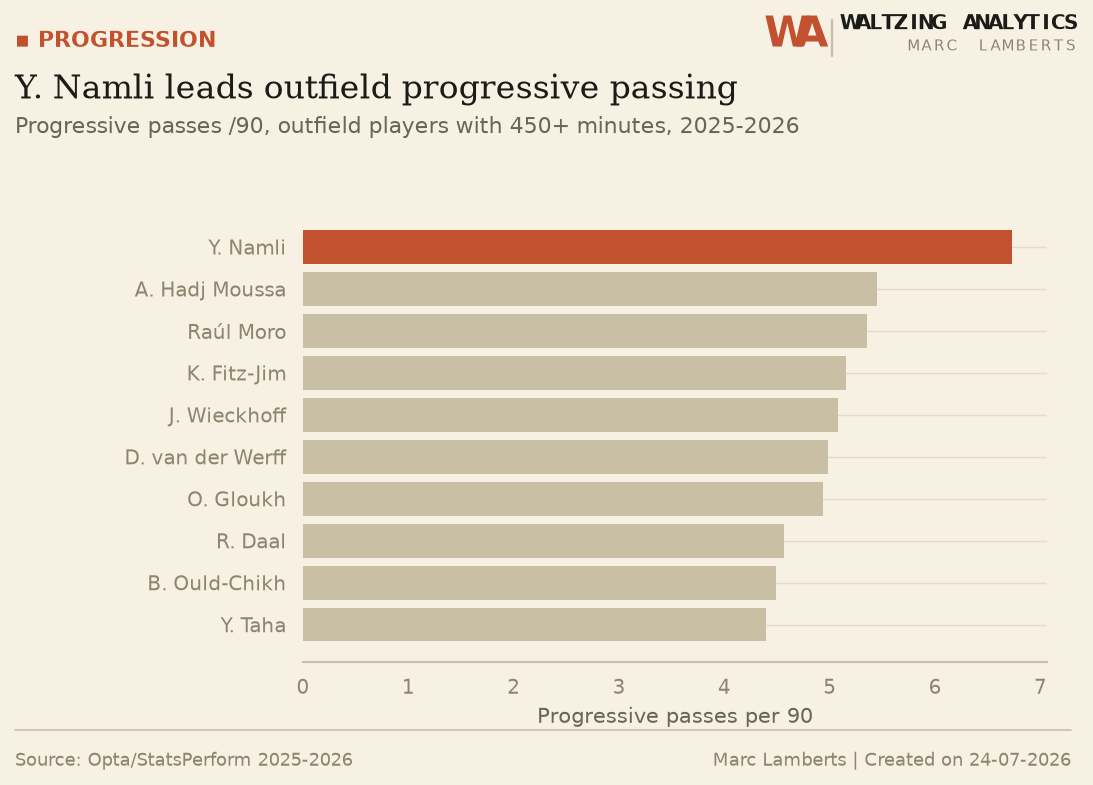

In [3]:
palette, _ = style.apply("light")
top10 = outfield.nlargest(10, "progressive_passes_per90").iloc[::-1]

fig = plt.figure(figsize=(8, 5.2))
ax = fig.add_axes([0.30, 0.16, 0.62, 0.58])
bars = ax.barh(top10["player_name"], top10["progressive_passes_per90"])
components.highlight_bars(bars, accent_index=len(top10) - 1, palette=palette)
ax.set_xlabel("Progressive passes per 90")

components.header(fig, kicker="Progression",
                   title=f"{top10.iloc[-1]['player_name']} leads outfield progressive passing",
                   dek=f"Progressive passes /90, outfield players with 450+ minutes, {SEASON}",
                   palette=palette)
components.footer(fig, source=f"Opta/StatsPerform {SEASON}", palette=palette)
plt.show()

## Creativity -- xA broken down by delivery type

Not just one blended "xA" -- `xa_cutback`, `xa_cross`, `xa_through_ball`,
`xa_set_piece` and `xa_open_play` are tracked separately (see Creativity tab
in the xlsx). The stacked bars below show, for the top 8 players by total
xA, *how* they created it.

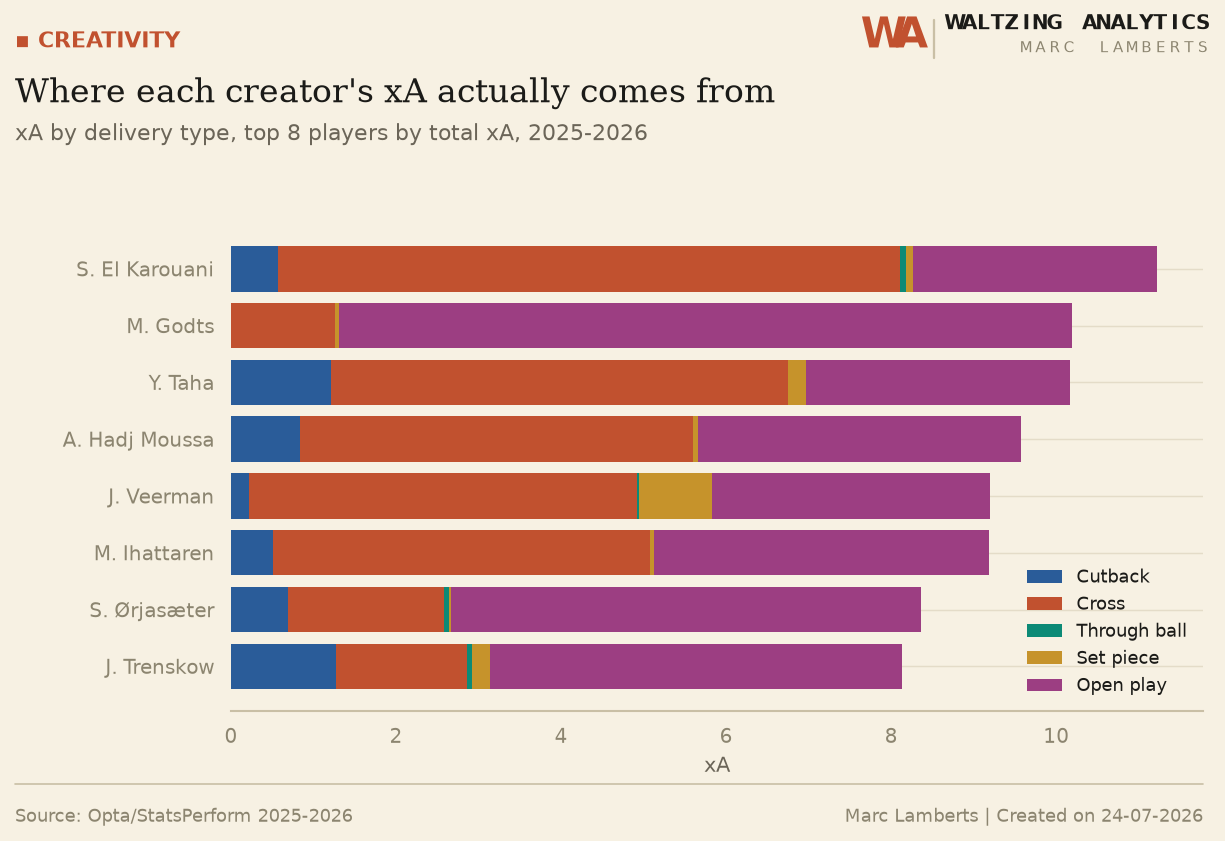

In [4]:
dtypes = ["cutback", "cross", "through_ball", "set_piece", "open_play"]
xa_cols = [f"xa_{t}" for t in dtypes]
top_creative = reliable.nlargest(8, "xa")[["player_name"] + xa_cols].set_index("player_name").iloc[::-1]

palette, cats = style.apply("light")
fig = plt.figure(figsize=(9, 5.6))
ax = fig.add_axes([0.22, 0.16, 0.72, 0.58])
left = pd.Series(0.0, index=top_creative.index)
labels = {"cutback": "Cutback", "cross": "Cross", "through_ball": "Through ball",
          "set_piece": "Set piece", "open_play": "Open play"}
for i, t in enumerate(dtypes):
    ax.barh(top_creative.index, top_creative[f"xa_{t}"], left=left, color=cats[i % len(cats)],
            label=labels[t])
    left += top_creative[f"xa_{t}"]
ax.legend(loc="lower right", frameon=False, fontsize=8.5)
ax.set_xlabel("xA")

components.header(fig, kicker="Creativity",
                   title="Where each creator's xA actually comes from",
                   dek=f"xA by delivery type, top 8 players by total xA, {SEASON}",
                   palette=palette)
components.footer(fig, source=f"Opta/StatsPerform {SEASON}", palette=palette)
plt.show()

## Defensive volume, possession-adjusted (PAdj)

Raw tackle/interception counts reward players on low-possession teams just
because their team faces the ball more. PAdj scales for that -- see the
formula in `README.md`.

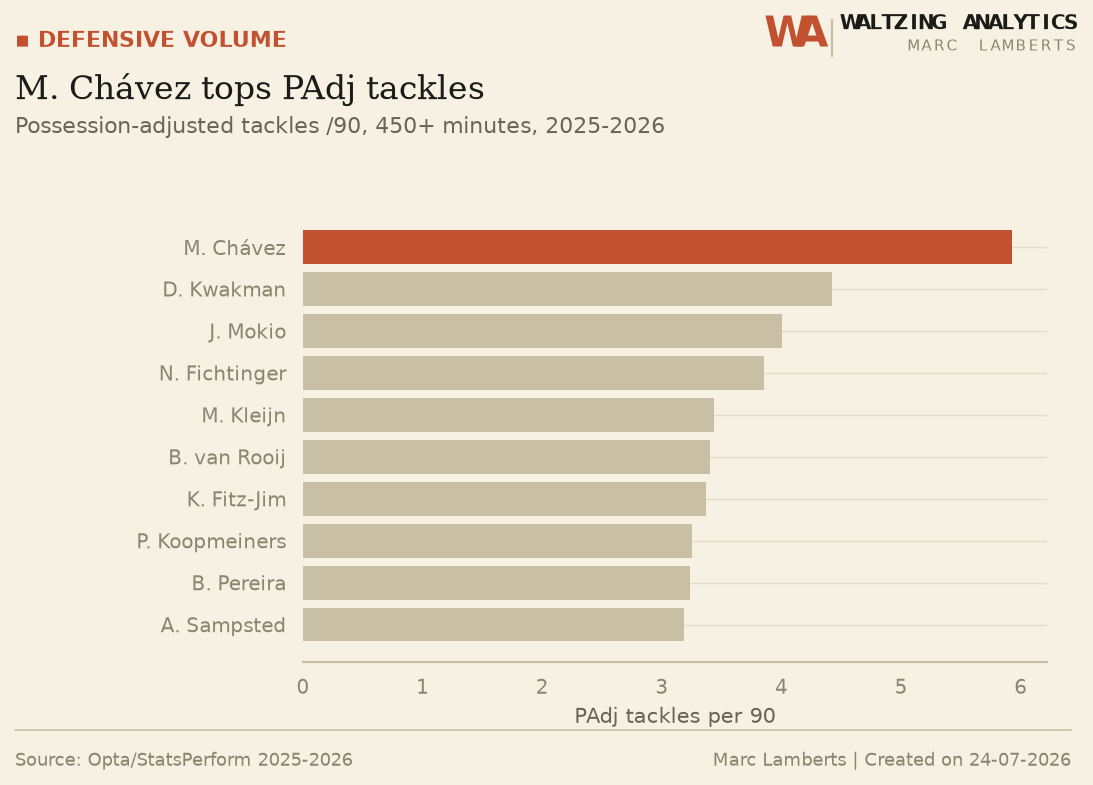

In [5]:
top_padj = reliable.nlargest(10, "padj_tackles_attempted_per90").iloc[::-1]

palette, _ = style.apply("light")
fig = plt.figure(figsize=(8, 5.2))
ax = fig.add_axes([0.30, 0.16, 0.62, 0.58])
bars = ax.barh(top_padj["player_name"], top_padj["padj_tackles_attempted_per90"])
components.highlight_bars(bars, accent_index=len(top_padj) - 1)
ax.set_xlabel("PAdj tackles per 90")

components.header(fig, kicker="Defensive Volume",
                   title=f"{top_padj.iloc[-1]['player_name']} tops PAdj tackles",
                   dek=f"Possession-adjusted tackles /90, 450+ minutes, {SEASON}",
                   palette=palette)
components.footer(fig, source=f"Opta/StatsPerform {SEASON}", palette=palette)
plt.show()

## Team table -- does more of the ball mean more points?

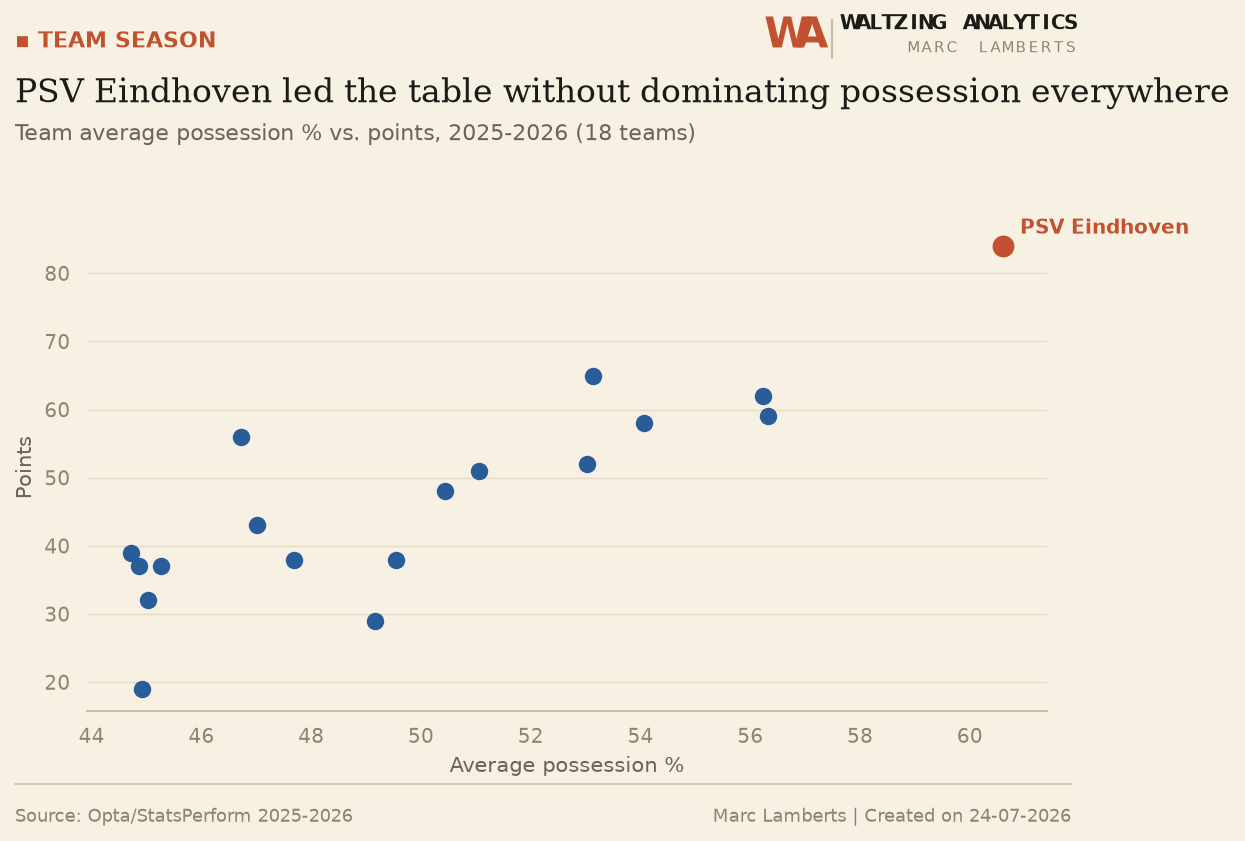

In [6]:
palette, cats = style.apply("light")
fig = plt.figure(figsize=(8, 5.6))
ax = fig.add_axes([0.12, 0.16, 0.80, 0.58])
ax.scatter(teams["possession_pct"], teams["points"], s=70, color=cats[0], zorder=3)
leader = teams.loc[teams["points"].idxmax()]
ax.scatter([leader["possession_pct"]], [leader["points"]], s=110, color=palette["accent"], zorder=4)
ax.annotate(leader["team_name"], xy=(leader["possession_pct"], leader["points"]),
            xytext=(8, 6), textcoords="offset points", fontsize=9.5, fontweight="bold",
            color=palette["accent"])
ax.set_xlabel("Average possession %")
ax.set_ylabel("Points")

components.header(fig, kicker="Team Season",
                   title=f"{leader['team_name']} led the table without dominating possession everywhere",
                   dek=f"Team average possession % vs. points, {SEASON} ({len(teams)} teams)",
                   palette=palette)
components.footer(fig, source=f"Opta/StatsPerform {SEASON}", palette=palette)
plt.show()

## Where to go from here

- Full column definitions, event-code reference, and every known
  face-validity caveat: `README.md` in this folder.
- Every metric split across categorised tabs, plus a Glossary tab:
  `eredivisie_2025-2026_aggregated.xlsx`.
- No composite score is produced anywhere in this pipeline -- see the
  README for why, and what a validated one would need.